# Gemma 4 E4B — Clone & Benchmark Notebook

Notebook untuk meng-clone model [google/gemma-4-E4B](https://huggingface.co/google/gemma-4-E4B) dari Hugging Face dan melakukan benchmark pada berbagai metrik:
- Kecepatan loading & memory usage
- Text generation throughput (tokens/sec)
- Reasoning & knowledge QA
- Coding capability
- Multimodal understanding (image)
- Long context retrieval

**Model**: `google/gemma-4-E4B-it` (instruction-tuned, 4.5B effective params, 8B total, 128K context)

**Cara pakai**: Runtime > Factory reset runtime, lalu Runtime > Run all

---
## 1. Environment Setup

In [7]:
# Install dependencies
!pip install -qU \
    'transformers>=4.50.0' \
    accelerate \
    sentencepiece \
    protobuf \
    psutil \
    'pillow<11' \
    requests \
    matplotlib \
    tabulate \
    librosa \
    soundfile \
    einops \
    bitsandbytes \
    2>&1 | tail -3
print("Install selesai")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00
Install selesai


In [8]:
import os, sys, json, time, gc, warnings
from pathlib import Path
from datetime import datetime
from IPython.display import display

import torch
import psutil
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from PIL import Image
import requests
from io import BytesIO

warnings.filterwarnings("ignore")

print(f"Python       : {sys.version}")
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA avail   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device  : {torch.cuda.get_device_name(0)}")
    print(f"CUDA VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"CUDA cap     : {torch.cuda.get_device_capability()}")

Python       : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch      : 2.11.0+cu128
CUDA avail   : True
CUDA device  : Tesla T4
CUDA VRAM    : 15.6 GB
CUDA cap     : (7, 5)


---
## 2. Clone Model from Hugging Face

Model size ~16 GB dalam BF16. Karena T4 hanya 15.6GB VRAM, kita perlu 4-bit quantization.

In [10]:
MODEL_ID = "google/gemma-4-E4B-it"
CACHE_DIR = None

print(f"Model ID: {MODEL_ID}")
print("Loading (4-bit quantized)...")
t0 = time.perf_counter()

from transformers import AutoProcessor, AutoModelForMultimodalLM, BitsAndBytesConfig
import accelerate

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

processor = AutoProcessor.from_pretrained(MODEL_ID, cache_dir=CACHE_DIR)
print(f"Processor loaded in {time.perf_counter()-t0:.1f}s")

load_start = time.perf_counter()
model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map={"": "cuda:0"},
    max_memory={0: "14GiB", "cpu": "48GiB"},
    cache_dir=CACHE_DIR,
    quantization_config=bnb_config,
)
load_time = time.perf_counter() - load_start
print(f"\nModel loaded in {load_time:.1f}s")

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params/1e9:.2f}B")
print(f"Device: {model.device}, Dtype: {model.dtype}")

Model ID: google/gemma-4-E4B-it
Loading (4-bit quantized)...
Processor loaded in 6.2s


Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]


Model loaded in 63.4s
Parameters: 5.72B
Device: cuda:0, Dtype: torch.bfloat16


In [11]:
if torch.cuda.is_available():
    vram_used = torch.cuda.memory_allocated() / 1e9
    print(f"VRAM allocated: {vram_used:.2f} GB")
ram_used = psutil.Process(os.getpid()).memory_info().rss / 1e9
print(f"RAM used: {ram_used:.2f} GB")

VRAM allocated: 9.32 GB
RAM used: 2.67 GB


---
## 3. Text Generation Throughput

In [12]:
def throughput(prompt, max_tokens=256, runs=3):
    msgs = [{"role": "user", "content": prompt}]
    inputs = processor.apply_chat_template(msgs, tokenize=True, return_dict=True,
                    return_tensors="pt", add_generation_prompt=True).to(model.device)
    inp_len = inputs["input_ids"].shape[-1]
    lats, toks = [], []
    for _ in range(runs):
        start = time.perf_counter()
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_tokens, do_sample=True, temperature=0.7)
        elapsed = time.perf_counter() - start
        gen = out[0][inp_len:]
        lats.append(elapsed)
        toks.append(len(gen))
    tps = [t/l for t,l in zip(toks, lats)]
    return {"prompt": prompt[:60]+"...", "tokens": int(np.mean(toks)),
            "latency": float(np.mean(lats)), "tps": float(np.mean(tps))}

prompts = {
    "Simple QA": "What is the capital of Indonesia?",
    "Math": "If a train travels at 120 km/h and another at 80 km/h toward each other from 500 km apart, how long until they meet?",
    "Code": "Write a Python function to find the longest palindromic substring.",
}

results = []
for name, p in prompts.items():
    r = throughput(p, runs=2)
    results.append(r)
    print(f"{name}: {r['tokens']} tok, {r['latency']:.1f}s, {r['tps']:.1f} tok/s")

Simple QA: 42 tok, 7.5s, 5.2 tok/s
Math: 217 tok, 37.3s, 5.8 tok/s
Code: 256 tok, 43.7s, 5.9 tok/s


---
## 4. Reasoning (MMLU-style)

In [13]:
mmlu = [
    {"q": "What is the time complexity of binary search?", "o": ["A. O(n)", "B. O(log n)", "C. O(n log n)", "D. O(1)"], "a": "B"},
    {"q": "Which planet has the strongest surface gravity?", "o": ["A. Earth", "B. Mars", "C. Jupiter", "D. Saturn"], "a": "C"},
    {"q": "In C++, which keyword prevents overriding?", "o": ["A. static", "B. const", "C. final", "D. override"], "a": "C"},
    {"q": "Probability of drawing a red ball from 3 red + 5 blue?", "o": ["A. 3/5", "B. 3/8", "C. 5/8", "D. 1/2"], "a": "B"},
    {"q": "What does mitochondria do?", "o": ["A. Protein", "B. Energy (ATP)", "C. Lipid", "D. DNA"], "a": "B"},
]

ok = 0
for q in mmlu:
    prompt = f"{q['q']}\n\n" + "\n".join(q["o"]) + "\n\nAnswer with a single letter:"
    inputs = processor.apply_chat_template([{"role":"user","content":prompt}],
        tokenize=True, return_dict=True, return_tensors="pt", add_generation_prompt=True).to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=8, do_sample=False)
    ans = processor.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
    cor = q["a"] in ans.upper()[:1]
    if cor: ok += 1
    print(f"  {'OK' if cor else 'NO'} Expected={q['a']} Got={ans[:20]} | {q['q'][:50]}")

print(f"\nAccuracy: {ok}/{len(mmlu)} = {ok/len(mmlu)*100:.0f}%")

  OK Expected=B Got=B | What is the time complexity of binary search?
  OK Expected=C Got=C | Which planet has the strongest surface gravity?
  OK Expected=C Got=C | In C++, which keyword prevents overriding?
  NO Expected=B Got=A | Probability of drawing a red ball from 3 red + 5 b
  OK Expected=B Got=B | What does mitochondria do?

Accuracy: 4/5 = 80%


---
## 5. Coding

In [14]:
for name, prompt in [
    ("Binary Search", "Write Python `binary_search(arr, target)` returning index or -1."),
    ("Fibonacci", "Write Python `fib(n)` for nth Fibonacci using DP."),
]:
    print(f"\n{'='*40}\n{name}\n{'='*40}")
    inputs = processor.apply_chat_template([{"role":"user","content":prompt}],
        tokenize=True, return_dict=True, return_tensors="pt", add_generation_prompt=True).to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=512, temperature=0.2, do_sample=False)
    print(processor.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)[:400])

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Binary Search
```python
def binary_search(arr, target):
    """
    Performs a binary search on a sorted array to find the target element.

    Args:
      arr: A sorted list of elements (the array to search).
      target: The element whose index is to be found.

    Returns:
      The index of the target if found, otherwise -1.
    """
    left = 0
    right = len(arr) - 1

    while left <= right:
        # 

Fibonacci
Here are several ways to implement the Fibonacci sequence function `fib(n)` using Dynamic Programming (DP) in Python, depending on whether you want to optimize for space or time complexity.

The standard Fibonacci sequence starts with $F_0 = 0$ and $F_1 = 1$.

---

## 1. Top-Down DP with Memoization (Recursive with Caching)

This is the most direct translation of applying DP to the recursive defin


---
## 6. Image Understanding

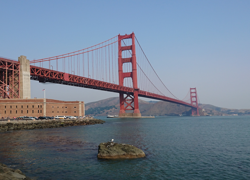

Time: 23.8s
This image displays a photograph featuring the **Golden Gate Bridge** spanning across a body of water toward a landmass in the distance.

Here is a brief description:

The dominant feature is the massive **red bridge structure** (clearly identifiable


In [15]:
try:
    url = "https://raw.githubusercontent.com/google-gemma/cookbook/main/apps/sample-data/GoldenGate.png"
    img = Image.open(BytesIO(requests.get(url, timeout=30).content))
    display(img.resize((250, 180)))
    inputs = processor.apply_chat_template([{"role":"user","content":[
        {"type":"image","image":img},
        {"type":"text","text":"What is shown? Describe briefly."}
    ]}], tokenize=True, return_dict=True, return_tensors="pt", add_generation_prompt=True).to(model.device)
    t0 = time.perf_counter()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=128, temperature=0.7, do_sample=True)
    print(f"Time: {time.perf_counter()-t0:.1f}s")
    print(processor.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)[:250])
except Exception as e:
    print(f"ERROR: {e}")

---
## 7. Long Context (Needle-in-Haystack)

In [17]:
torch.cuda.empty_cache()
gc.collect()

def needle(pos):
    needle_str = "The secret code is BLUE-42-GREEN."
    filler = "The quick brown fox jumps over the lazy dog. Python is versatile. "
    sents = [filler] * 50  # shorter context for T4
    if pos == "early": sents.insert(0, needle_str)
    elif pos == "middle": sents.insert(len(sents)//2, needle_str)
    else: sents.append(needle_str)
    prompt = f"Read the text and answer.\n\nText: {' '.join(sents)}\n\nQ: What is the secret code? Answer with code only."
    inputs = processor.apply_chat_template([{"role":"user","content":prompt}],
        tokenize=True, return_dict=True, return_tensors="pt", add_generation_prompt=True).to(model.device)
    t0 = time.perf_counter()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=16, do_sample=False)
    resp = processor.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
    return {"pos": pos, "tokens": inputs["input_ids"].shape[-1], "resp": resp[:80],
            "correct": "BLUE-42-GREEN" in resp, "time": time.perf_counter()-t0}

print("Needle-in-Haystack:")
for p in ["early", "middle", "late"]:
    r = needle(p)
    print(f"{p.upper()}: {r['tokens']} tok, correct={'OK' if r['correct'] else 'NO'}, {r['time']:.1f}s")

Needle-in-Haystack:
EARLY: 793 tok, correct=OK, 4.9s
MIDDLE: 793 tok, correct=OK, 5.0s
LATE: 793 tok, correct=OK, 5.0s


---
## 8. Summary

In [18]:
rows = [
    ["Model", MODEL_ID],
    ["Parameters", f"{total_params/1e9:.2f}B"],
    ["Device", str(model.device)],
]
if torch.cuda.is_available(): rows.append(["VRAM", f"{torch.cuda.memory_allocated()/1e9:.2f} GB"])
rows.append(["RAM", f"{ram_used:.2f} GB"])
rows.append(["Load Time", f"{load_time:.1f}s"])
if results: rows.append(["Throughput", f"{np.mean([r['tps'] for r in results]):.1f} tok/s"])
rows.append(["MMLU", f"{ok}/{len(mmlu)} ({ok/len(mmlu)*100:.0f}%)"])

print("="*60)
print("  GEMMA 4 E4B — SUMMARY")
print("="*60)
print(tabulate(rows, headers=["Metric","Value"], tablefmt="grid"))
print("="*60)

  GEMMA 4 E4B — SUMMARY
+------------+-----------------------+
| Metric     | Value                 |
+============+=======================+
| Model      | google/gemma-4-E4B-it |
+------------+-----------------------+
| Parameters | 5.72B                 |
+------------+-----------------------+
| Device     | cuda:0                |
+------------+-----------------------+
| VRAM       | 10.26 GB              |
+------------+-----------------------+
| RAM        | 2.67 GB               |
+------------+-----------------------+
| Load Time  | 63.4s                 |
+------------+-----------------------+
| Throughput | 5.6 tok/s             |
+------------+-----------------------+
| MMLU       | 4/5 (80%)             |
+------------+-----------------------+


---
## 9. Cleanup

In [19]:
del model, processor
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("Done.")

VRAM: 10.26 GB
Done.
